# Предсказание просрочки клатежа по кредиту

## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.

## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


### План работы
#### Цель проекта
Разработать модель бинарной классификации, которая спрогнозирует факт просрочки платежей по кредиту.

#### Суть проекта
Предсказать вероятность того, что клиент банка совершит просрочку платежа по кредиту длительностью от 90 дней. Объект моделирования — это клиент в конкретный месяц, целевая переменная — столбец, содержащий данные о том, будет ли у клиента просрочка от 90 дней в течение ближайших 12 месяцев.

#### Описание проекта
Модель будет вляться моделью нелинейной бинарной классификации с временной структурой. Целевой переменной будет факт просрочки более 90 дней. Для оценки будем использовать метрики бизнес метрики approval rate, default rate и missed defaults rate, дополнительно будет использована метрика ROC-AUC. В оценке финальной модели важно соблюсти баланс:
- Approval rate не менее 65%
- Default rate не более 2%
- Missed defaults rate не более 4%

#### Задачи проекта
1. Подготовка рабочего пространства
2. Перевод бизнес-задачи на язык машинного обучения
3. Загрузка необходимых библиотек
4. Загрузка данных
5. Исследовательский анализ данных
6. Объединение таблиц
7. Создание новых признаков
8. Анализ итоговой таблицы
9. Моделирование
10. Калибровка модели и пересчёт результатов
11. Поиск порога решения
12. Анализ матрицы ошибок
13. Фиксирование итоговой модели
14. Анализ важности признаков
15. Выводы по проекту

#### Исходные данные.

  * `'/datasets/ds_15_loan_payment_credit.csv'` - Данные о просрочке платежа
  * `'/datasets/ds_15_transactions.csv'` - Месячные транзакции клиента
  * `'/datasets/ds_15_client_description.csv'` - Описание клиента на момент регистрации в банке
  * `'/datasets/ds_15_credit_description.csv'` - Описание кредита
  * `'/datasets/ds_15_mortgage_presence.csv'` - Данные о наличии ипотеки
  * `'/datasets/ds_15_credit_rating.csv'` - Данные о кредитном рейтинге клиента
  * `'/datasets/ds_15_macro_data.csv'` - Данные о макроэкономических показателях России
  * `'/datasets/ds_15_cohort_grid.csv'` - Данные о дате проведения поведенческого скоринга

## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [2]:
from IPython import display
from jinja2.utils import missing
!pip install "scikit-learn==1.6.1" "numpy==2.4.3" "optuna==4.8.0" -U -q
!pip install phik -U -q
!pip install ipywidgets -U -q

ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0 Requires-Python >=3.11; 1.8.0rc1 Requires-Python >=3.11; 2.1.0 Requires-Python >=3.10; 2.1.1 Requires-Python >=3.10; 2.1.2 Requires-Python >=3.10; 2.1.3 Requires-Python >=3.10; 2.2.0 Requires-Python >=3.10; 2.2.1 Requires-Python >=3.10; 2.2.2 Requires-Python >=3.10; 2.2.3 Requires-Python >=3.10; 2.2.4 Requires-Python >=3.10; 2.2.5 Requires-Python >=3.10; 2.2.6 Requires-Python >=3.10; 2.3.0 Requires-Python >=3.11; 2.3.1 Requires-Python >=3.11; 2.3.2 Requires-Python >=3.11; 2.3.3 Requires-Python >=3.11; 2.3.4 Requires-Python >=3.11; 2.3.5 Requires-Python >=3.11; 2.4.0 Requires-Python >=3.11; 2.4.0rc1 Requires-Python >=3.11; 2.4.1 Requires-Python >=3.11; 2.4.2 Requires-Python >=3.11; 2.4.3 Requires-Python >=3.11; 2.4.4 Requires-Python >=3.11
ERROR: Could not find a version that satisf

In [3]:
#Импорт библиотек
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import phik
from time import time
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    root_mean_squared_error,
    mean_squared_error,
    r2_score
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.inspection import permutation_importance
import numpy as np
import joblib
import optuna
from IPython.display import HTML

In [4]:
# Зафиксируем константы для воспроизводимости
RANDOM_STATE = 42
N_FOLDS = 5

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

In [5]:
datasets = dict(
    links=dict(
        loan_payment_credit='datasets/ds_15_loan_payment_credit.csv',
        transactions='datasets/ds_15_transactions.csv',
        client_description='datasets/ds_15_client_description.csv',
        credit_description='datasets/ds_15_credit_description.csv',
        mortgage_presence='datasets/ds_15_mortgage_presence.csv',
        credit_rating='datasets/ds_15_credit_rating.csv',
        macro_data='datasets/ds_15_macro_data.csv',
        cohort_grid='datasets/ds_15_cohort_grid.csv',
    )
)
for name, link in datasets['links'].items():
    file_path_platform = Path('/' + link)
    file_path_local = Path(link)
    if file_path_platform.exists():
        datasets[name] = pd.read_csv(file_path_platform, sep=',', decimal='.')
        print(f'Загружен файл {file_path_platform}')
    elif file_path_local.exists():
        datasets[name] = pd.read_csv(file_path_local, sep=',', decimal='.')
        print(f'Загружен файл {file_path_local}')
    else:
        print(f'Ошибка загрузки файла - "{name}"')

Загружен файл datasets/ds_15_loan_payment_credit.csv
Загружен файл datasets/ds_15_transactions.csv
Загружен файл datasets/ds_15_client_description.csv
Загружен файл datasets/ds_15_credit_description.csv
Загружен файл datasets/ds_15_mortgage_presence.csv
Загружен файл datasets/ds_15_credit_rating.csv
Загружен файл datasets/ds_15_macro_data.csv
Загружен файл datasets/ds_15_cohort_grid.csv


## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [101]:
# Класс для первичного исследования данных в датафрейме
class DataFrameReporter:
    def __init__(
        self, df, df_name=None, float_round=3,
        percent_format='0.02%', include_all=False
    ):
        self.df = df
        self.df_name = df_name
        self.float_round = float_round
        self.float_format = f'0.0{float_round}f'
        self.percent_format = percent_format
        self.include_all = include_all

    def show_base_info(self):
        if self.df_name:
            print(f'Базовая информация по датасету {self.df_name}:')
            print('-' * 50)
        display(self.df.head(5))
        display(self.df.info())

    def show_report(self):
        if self.df_name:
            print(f'Отчёт по датасету {self.df_name}:')
            print('-' * 50)
        print('Количество столбцов:', self.df.shape[1])
        print('Количество строк:', self.df.shape[0])
        duplicates = self.df.duplicated().sum()
        print('Количество дубликатов:', duplicates)
        print('Доля дубликатов:', format(
            duplicates / self.df.shape[0], self.percent_format
        ))
        num_cols = self.df.select_dtypes(
            include=['int64', 'float64']).columns.tolist()
        display(self.df[num_cols].agg(
            ['count', 'min', 'max', 'std', 'mean', 'median']
        ).T.round(self.float_round))
        missing = self.df.isna().sum().sum()
        print('Количество пропусков:', missing)
        if missing:
            display(self.show_missing_stats())
        isna = self.df.isna().mean(axis=None).sum()
        print('Доля пропусков:', format(isna, self.float_format))

    def show_missing_stats(self):
        missing_stats = pd.DataFrame({
            'Кол-во пропусков': self.df.isnull().sum(),
            'Доля пропусков': self.df.isnull().mean().round(4)
        })
        missing_stats = missing_stats[
            missing_stats['Кол-во пропусков'] > 0
        ].sort_values(by='Кол-во пропусков', ascending=False)
        return missing_stats.style.background_gradient(
            cmap='coolwarm'
        ) if not missing_stats.empty else "Пропусков в данных нет"

    def show_duplicates(self, columns=None):
        if not columns:
            columns = self.df.columns
        duplicates_per_column = {
            col: self.df[col].duplicated().sum() for col in columns
        }
        duplicates_per_column_stats = pd.DataFrame.from_dict(
            duplicates_per_column,
            orient='index',
            columns=['Количество дубликатов']
        )
        return duplicates_per_column_stats.style.background_gradient(
            cmap='coolwarm').set_caption("Статистика дубликатов по столбцам")

    def show_implicit_duplicates_stats(self, columns):
        duplicates = {
            col: self.df[col].nunique() - self.df[
                col].str.strip().str.lower().nunique()
            for col in columns
        }
        duplicates_stats = pd.DataFrame(
            list(duplicates.items()),
            columns=["Столбец", "Неявных дубликатов"]
        )
        return duplicates_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption("Статистика неявных дубликатов")

    def show_uniques_stats(self, columns):
        uniques = {}
        unique_values = {}
        for col in columns:
            uniques[col] = self.df[col].nunique()
            unique_values[col] = ', '.join(
                [str(x) for x in self.df[col].unique()]
            )
        uniques_stats = pd.DataFrame(
            list(uniques.items()),
            columns=['Столбец', 'Уникальных значений']
        )
        uniques_stats['Уникальные значения'] = uniques_stats[
            'Столбец'].map(unique_values)

        display(uniques_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption('Статистика уникальных значений'))

### ИАД loan_payment_credit

In [102]:
reporter = DataFrameReporter(datasets['loan_payment_credit'], 'loan_payment_credit')
reporter.show_base_info()

Базовая информация по датасету loan_payment_credit:
--------------------------------------------------


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   5500 non-null   str  
 1   дата_начала_периода  5500 non-null   str  
 2   просрочка_дней       5500 non-null   int64
dtypes: int64(1), str(2)
memory usage: 129.0 KB


None

In [103]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету loan_payment_credit:
--------------------------------------------------
Количество столбцов: 3
Количество строк: 5500
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
просрочка_дней,5500.0,80.0,150.0,20.362,114.748,115.0


Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,0


In [122]:
# Функция для отрисовки распределения по
def plot_distribution(
        dataset, cols,
        figsize=(16, 4), fontsize=12, bins=40, density=True
):
    color = 'steelblue'
    y_label = 'Плотность' if density else 'Частота'

    for col in cols:
        fig, axes = plt.subplots(
            1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2, 1]}
        )
        all_data = []
        all_labels = []

        ax1 = axes[0]
        data = dataset[col].dropna()
        all_data.append(data)
        all_labels.append(name)

        ax1.hist(
            data, bins=bins, alpha=0.5, label=name,
            color=color, edgecolor='black', density=density
        )

        ax1.set_title(f'Распределение {col}', fontsize=fontsize, fontweight='bold')
        ax1.set_xlabel(col)
        ax1.set_ylabel(y_label)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = axes[1]
        box = ax2.boxplot(all_data, vert=True, patch_artist=True, tick_labels=all_labels)

        for i, patch in enumerate(box['boxes']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax2.set_ylabel(col)
        ax2.set_title('Ящик с усами', fontsize=fontsize, fontweight='bold')
        ax2.grid(True, alpha=0.2, axis='y')

        plt.tight_layout()
        plt.show()

In [124]:
# Функция для отрисовки категориальных признаков
def plot_cat_distribution(dataset, categorical_features):
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.ravel()

    for idx, feature in enumerate(categorical_features):
        sns.boxplot(data=dataset, x=feature, y='rented_bike_count',
                    ax=axes[idx], palette='Set2', hue=feature, legend=False, width=0.2)
        axes[idx].set_title(f'Распределение аренды по {feature}')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Количество аренд')
        axes[idx].tick_params(axis='x')

    for idx in range(len(categorical_features), len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

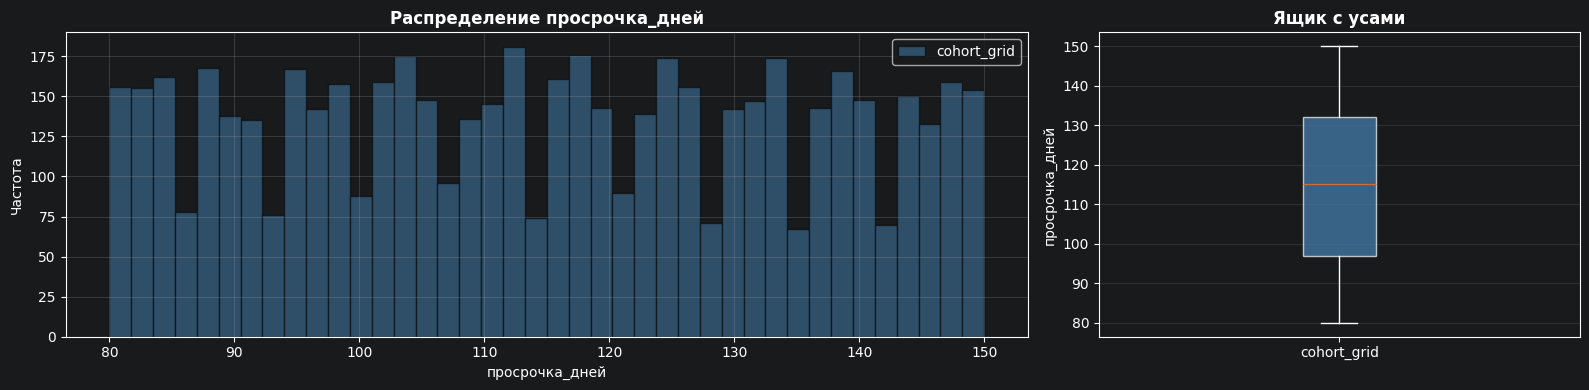

In [127]:
plot_distribution(datasets['loan_payment_credit'], ['просрочка_дней'], density=False)

---
Датасет `ds_15_loan_payment_credit.csv` содержит 3 столбца и 5500 строк, в которых представлена информация о просрочках платежа.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `дата_начала_периода` содержит дату и хранится в типе данных `str`, тип данных следует преобразовать в `datetime64`.
- Столбец `просрочка_дней` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

-- В данных отсутствуют пропуски и дубликаты.

---

### ИАД transactions

In [66]:
reporter = DataFrameReporter(datasets['transactions'], 'transactions')
reporter.show_base_info()

Базовая информация по датасету transactions:
--------------------------------------------------


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  str    
 1   date        577494 non-null  str    
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), str(2)
memory usage: 44.1 MB


None

In [67]:
reporter.show_report()

Отчёт по датасету transactions:
--------------------------------------------------
Количество столбцов: 10
Количество строк: 577494
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
MCC_5300,577494.0,162.91,86939.40,8835.872,6177.123,2659.590
MCC_5814,577494.0,62.18,55720.69,5710.755,3507.682,1233.110
MCC_5812,577494.0,67.06,47969.57,4541.120,2993.863,1224.530
MCC_5411,577494.0,286.11,101301.95,12299.733,9263.100,4115.385
MCC_3990,577494.0,31.90,14261.49,1557.157,1128.117,476.890
MCC_5722,577494.0,108.40,54630.19,5005.897,3604.437,1590.120
MCC_4900,577494.0,81.29,52987.53,5567.979,3682.487,1397.065
MCC_другое,577494.0,166.26,60033.55,7190.882,5414.897,2398.330


Количество пропусков: 0
Доля пропусков: 0.000


---
Датасет `ds_15_transactions.csv` содержит 10 столбцов и 577494 строк, в которых представлена информация о тратах клиента по MCC-кодам.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `date` содержит дату и хранится в типе данных `str`, тип данных следует преобразовать в `datetime64`.
- Столбец `MCC_5300` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5814` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5812` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5411` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5722` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_4900` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_другое` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

In [8]:
datasets['client_description'].info()
datasets['client_description'].head(5)

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  13500 non-null  str  
 1   возраст             13500 non-null  int64
 2   семейное_положение  13500 non-null  str  
 3   наличие_иждивенцев  13500 non-null  int64
 4   дата_регистрации    13500 non-null  str  
dtypes: int64(2), str(3)
memory usage: 527.5 KB


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


---
Датасет `ds_15_client_description.csv` содержит 5 столбцов и 13500 строк, в которых представлено описание клиента на момент регистрации в банке.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `возраст` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Столбец `семейное_положение` содержит категориальную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Столбец `наличие_иждивенцев` содержит бинарную информацию и хранится в типе данных `int64`, тип данных можно привести к `bool`.
- Столбец `дата_регистрации` содержит дату и хранится в типе данных `str`, тип данных следует преобразовать в `datetime`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

In [9]:
datasets['credit_description'].info()
datasets['credit_description'].head(5)

<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             13500 non-null  str  
 1   доход          13500 non-null  int64
 2   сумма_кредита  13500 non-null  int64
dtypes: int64(2), str(1)
memory usage: 316.5 KB


,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


---
Датасет `ds_15_credit_description.csv` содержит 3 столбцов и 13500 строк, в которых представлено описание кредита.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `доход` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Столбец `сумма_кредита` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

In [10]:
datasets['mortgage_presence'].info()
datasets['mortgage_presence'].head(5)

<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               6609 non-null   str  
 1   дата_открытия    6609 non-null   str  
 2   наличие_ипотеки  6609 non-null   int64
dtypes: int64(1), str(2)
memory usage: 155.0 KB


,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


---
Датасет `ds_15_mortgage_presence.csv` содержит 3 столбцов и 6609 строк, в которых представлены данные о наличии ипотеки.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `дата_открытия` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Столбец `наличие_ипотеки` содержит бинарные данные и хранится в типе данных `int64`, тип данных следует привести к `bool`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

In [11]:
datasets['credit_rating'].info()
datasets['credit_rating'].head(5)

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ID                 577494 non-null  str  
 1   date               577494 non-null  str  
 2   кредитный_рейтинг  577494 non-null  int64
dtypes: int64(1), str(2)
memory usage: 13.2 MB


,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


---
Датасет `ds_15_credit_rating.csv` содержит 3 столбцов и 577494 строк, в которых представлены данные о кредитном рейтинге клиента.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `date` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Столбец `кредитный_рейтинг` содержит целочисленные данные и хранится в типе данных `int64`, размерность данных можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

In [12]:
datasets['macro_data'].info()
datasets['macro_data'].head(5)

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     str    
 1   учетная_ставка       84 non-null     float64
 2   уровень_безработицы  84 non-null     float64
 3   инфляция             84 non-null     float64
dtypes: float64(3), str(1)
memory usage: 2.8 KB


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


---
Датасет `ds_15_macro_data.csv` содержит 4 столбцов и 84 строк, в которых представлены данные о макроэкономических показателях России.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбец `date` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Столбец `учетная_ставка` содержит цисла с плавающей точкой и хранится в типе данных `float64`, размерность данных можно оптимизировать.
- Столбец `уровень_безработицы` содержит цисла с плавающей точкой и хранится в типе данных `float64`, размерность данных можно оптимизировать.
- Столбец `инфляция` содержит цисла с плавающей точкой и хранится в типе данных `float64`, размерность данных можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---


In [13]:
datasets['cohort_grid'].info()
datasets['cohort_grid'].head(5)

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ID          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


---
Датасет `ds_15_macro_data.csv` содержит 4 столбцов и 84 строк, в которых представлены данные о дате проведения поведенческого скоринга.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `score_date` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---


## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.



https://github.com/msesemov/DS_RandomForest_Sprint_15